In [1]:

import numpy as np

import ngsolve 
from ngsolve.webgui import Draw
import netgen.geom2d

We find that perhaps sensiviity to boundary with brusselator and neuman bc is an artifact of 
1)  using initial condition of white noise generated by hand with vectors
2)  having initial condition means away from mean steady state solution
3)  having coarser elements
4)  using by-hand non-linear update which might be more sensitive to the element shapes and sizes



# Solving Reaction Diffusion equation pattern formation PDEs with a finite element method

We have two scalar fields $u,v$ in domain $\Omega$ that are also functions of time. 
The problem we will solve is the reaction diffusion equations 
\begin{align}
\partial_t u &= D_u \Delta u + R_u(u,v) \qquad \in \Omega\\
\partial_t v &= D_v \Delta v + R_v(u,v) 
\end{align}
For the Brusselator model the reactions between the two fields are the non-linear functions 
\begin{align}
R_u(u,v) &=  \alpha - (\beta+1) u + u^2 v \\    
    R_v(u,v) &= \beta u - u^2 v
\end{align}
Here $D_u,D_v$ are diffusion coefficients and $\alpha, \beta$ are parameters for the reaction part of the model.
For certain values of $\alpha, \beta$, random but small initial conditions, when evolved, become patterns. 

The coupled PDE for the Brusselator model is obeyed in the domain $\Omega$, 
but on the boundary  $\partial \Omega$ we set $\frac{\partial u}{\partial n} = \frac{\partial u}{\partial n} = 0 $. 
This is a Neumann boundary condition. 

The weak/variational form of the problem is 
\begin{align}
\int_\Omega \partial_t u\ w_u\ dx &= \int_\Omega D_u (\Delta u) w_u \ dx + \int_\Omega R_u(u,v)w_u \ dx\\
\int_\Omega \partial_t v\ w_v\ dx &= \int_\Omega D_v (\Delta v) w_v \ dx + \int_\Omega R_v(u,v)w_v \ dx
\end{align}
for all test functions $w_u, w_v \in \hat V$ where we will define $\hat V$.  
We integrate by parts the terms that contain a Laplacian operator 
\begin{align}
\int_\Omega \partial_t u\ w_u \ dx =   - D_u  \int_\Omega \nabla u \nabla w_u \ dx 
+ D_u\int_{\partial \Omega} \nabla u\ w_u \ ds
+  \int_\Omega R_u(u,v)w_u \ dx \\
 \int_\Omega \partial_t v\ w_v \ dx =  - D_v \int_\Omega \nabla v \nabla w_v \ dx 
+ D_v \int_{\partial \Omega} \nabla v\ w_v \ ds
+  \int_\Omega R_v(u,v)w_v \ dx 
\end{align}
With normal derivatives of $u,v$ equal to zero on the boundary, the two boundary terms in the above
equations can be neglected.
The weak form should be obeyed for all test functions $w \in \hat V$ with $\hat V = H^1(\Omega)$.
Since we lack Dirichlet regions of the boundary, there is no additional condition on $\hat V$. 
 We are following section 2.2.1 of the Fenics book.

We use a discrete subspace for $\hat V$ and assume we have a nice basis for it. 
We write each term as if it were an operator acting on a vector $w$ (aka the test function) in this basis. 

We split each time step into two pieces.  First updating $u,v$ with an implicit Crank-Nicholson step and 
then we take a first order forward Eulerian step to take into account the functions $R_u, R_v$. 

The Crank-Nicolson step for  $\partial_t u = F u  $  with $F$ a linear op is the following scheme 
\begin{align}
\partial_t u \sim \frac{u^{n+1} - u^n}{\Delta t} = \frac{1}{2} \left(F u^{n+1} + F u^n\right)
\end{align}
\begin{align}
\left( 1 - \frac{\Delta t F}{2 } \right) u^{n+1} = \left(1 + \frac{\Delta t F}{2 } \right) u^n \end{align}
\begin{align}
u^{n+1} = \left( 1 - \frac{ \Delta tF}{2} \right)^{-1} \left(1 + \frac{\Delta t F}{2 } \right)u^n
\end{align}
In the limit of small $\Delta t$ this is equivalent to a foward Eulerian scheme. 

With $m(u,v) = \int u v dx  = M u $ a mass operator and $a(u,v) = \int \nabla u \nabla v dx  = -F u $  a Laplacian operator
The above scheme becomes 
\begin{align}
u^{n+1} = \left( M - \frac{ \Delta tF}{2} \right)^{-1} \left(M + \frac{\Delta t F}{2 } \right)u^n
\end{align}

Taking into account the reaction equations for a diffusion reaction system 
\begin{align}
u^{n+1} &= \left( 1 - \frac{ \Delta t}{2 }D_u L \right)^{-1} \left(1 + \frac{\Delta t}{2 }D_uL  \right)u^n + 
\Delta t R_u(u^n,v^n)\\
v^{n+1} &= \left( 1 - \frac{\Delta t }{2 } D_v L\right)^{-1} \left(1 + \frac{\Delta t}{2 } D_vL\right)v^n + 
\Delta t R_v(u^n,v^n)
\end{align}
where $L$ is minus the Laplacian operator. 


For our system 
\begin{align}
b &= M - \frac{\Delta t}{2} L\\
A* &= M +\frac{\Delta t}{2} L
\end{align}
with 
\begin{align}
M(u,v,w_u, w_v) & = \int (u w_u +  v  w_v) dx \\
L(u,v,w_u,w_v) & = \int (D_u \nabla u \nabla w_u + D_v \nabla v \nabla w_v) dx
\end{align}

An incremental version of the scheme is 
\begin{align}
u^{n+1} - u^n &= \left( 1 - \frac{ \Delta t}{2 }D_u L \right)^{-1} (- \Delta t D_u L u^n )  + \Delta t R_u(u^n,v^n)\\ 
v^{n+1}- v^n &= \left( 1 - \frac{\Delta t }{2 } D_v L\right)^{-1} (- \Delta t D_v L v^n )  + \Delta t R_v(u^n,v^n)
\end{align}


This gives 
\begin{align}
d{\bf u} = (A*)^{-1} L \Delta t  + \text{nonlinear part}
\end{align}

We use the incremental version of the scheme because the inverse matrix is computed only for internal nodes
and so respects a non-zero Dirichlet boundary.  Otherwise the boundary nodes are set to zero when updated. 


# A pattern formation model finite element model with NGsolve!

In [2]:
# Reaction parts of differential equations for 
# different types of different Reaction diffusion equations
# u,v are scalar fields, alpha, beta could be numbers or arrays with same dimension as fields
# rdtype is a string specifying the model
def Reaction(u,v,alpha,beta,rdtype):
    if (rdtype == 'FN'):  # FitzHugh Nagumo model
        Ru,Rv=R_FN(u,v,alpha,beta)
        return Ru,Rv
    if (rdtype == 'Br'):  # Brusellator model
        Ru,Rv= R_Br(u,v,alpha,beta)
        return Ru,Rv
    if (rdtype == 'GS'):  # Gray-Scott model
        Ru,Rv = R_GS(u,v,alpha,beta)
        return Ru,Rv
    if (rdtype == 'Ba'):   # Barkley model 
        epsilon = 0.02  # choosing this value
        Ru,Rv = R_Ba(u,v,alpha,beta,epsilon)
        return Ru,Rv
    if (rdtype == 'Heat'):  # Heat equation 
        n = len(u)
        Ru = np.zeros(n); Rv = np.zeros(n)
        return Ru,Rv
    print('invalid reaction type')

#The FitzHugh-Nagumo Reaction Diffusion Model
# example: Du, Dv, alpha, beta = 1, 10, 0.1, 1, dt=0.01, dx = 1
def R_FN(u,v,alpha,beta): 
    Ru =  u - u**3 - v + alpha 
    Rv = (u - v)*beta
    return Ru,Rv
    
# Brusselator Reaction Diffusion model
# example: Du, Dv, alpha, beta = 2, 22, 5, 9 # dt=0.005, dx=1
# u = alpha, v = beta/alpha is a fixed point of R
def R_Br(u,v,alpha,beta): 
    Ru = alpha - (beta+1)*u + (u**2)*v    
    Rv = beta*u - (u**2)*v
    return Ru,Rv

# The Gray-Scott Reaction Diffusion model
# alpha is feed rate for u and kills v, beta is kill or drain rate for v
# example: Du = 0.2, Dv = Du/2, alpha = 0.037 and beta = 0.06 , dx=1
def R_GS(u,v,alpha,beta): 
    Ru =  -u*(v**2) + alpha*(1-u) 
    Rv =  u*(v**2) -(alpha+ beta)*v
    return Ru,Rv

# the Barkley model 
# http://www.scholarpedia.org/article/Barkley_model
# example epsilon=0.02, alpha = 0.75, beta = 0.02, domain = 200, dt = 0.01
def R_Ba(u,v,alpha,beta,epsilon): 
    Ru =  (1/epsilon)*u*(1-u)*(u - (v + beta)/alpha) 
    Rv =  u-v
    return Ru,Rv

In [3]:
# create operators, all are linear 
# input arguments:
#   fes: finite element space
#   Du, Dv: diffusion coefficients for each field 
#   dt: timestep, needed for creation of Crank-Nicholson operators 
# returns:
#   invm: inverse of mass matrix M^-1
#   a_lap=L:  laplacian bilinear operators times diffusion coefficients 
#   b:  where b = M - 0.5*L*dt  # needed for Crank Nicholson update 
#   invastr: = inverse of A* where  A* = M + 0.5 * L * dt 
def mkops(fes,D_u,D_v,dt):
    (u1,u2),(v1,v2)  = fes.TnT()
    a_lap = ngsolve.BilinearForm(fes)  # holds Laplacian operator for both fields 
    a_lap += 1*D_u*ngsolve.grad(u1)*ngsolve.grad(v1)*ngsolve.dx # This is laplacian with a diffusion coef on the first field
    a_lap += 1*D_v*ngsolve.grad(u2)*ngsolve.grad(v2)*ngsolve.dx # second field
    a_lap.Assemble()

    m = ngsolve.BilinearForm(fes)  # hold mass matrix for both fields 
    m += u1*v1*ngsolve.dx + u2*v2*ngsolve.dx
    m.Assemble()

    invm = m.mat.Inverse(freedofs=fes.FreeDofs())  # inverse of mass matrix!

    #print(f"m.mat.nze = {m.mat.nze}, a1.mat.nze={a.mat.nze}") # check that they are the same
    # these are the number of nonzero elements in the sparse matrices

    # B = M - 0.5*L*dt , needed for Crank Nicholson update L = Laplacian times diffusion coeffs, M = mass matrix
    b = m.mat.CreateMatrix()
    b.AsVector().data     = m.mat.AsVector() - 0.5*dt * a_lap.mat.AsVector()
    #print(f"b.nze = {b.nze}")

    # A* = M + 0.5 * L * dt   needed for Crank Nicholson incremental update 
    astar = m.mat.CreateMatrix() # create a matrix in the form of m
    astar.AsVector().data = m.mat.AsVector() + 0.5*dt * a_lap.mat.AsVector()
    invastar = astar.Inverse(freedofs=fes.FreeDofs())
    #print(f"astar.nze={astar.nze}")
    return invastar,a_lap,b,invm



In [4]:
# create initial conditions!
# https://docu.ngsolve.org/latest/i-tutorials/unit-2.2-eigenvalues/pinvit.html 
# see this for how to do random initial conditions! 

#steady state for brusellator is u0 = alpha;  v0 = beta/alpha;  5.; 9.

# set initial conditions into gfu
# parameters:
#  gfu is output grid function
#  mesh: ngsolve mesh
#  sig0: width of random uniform initial conditions 
#  u0, v0 constant offsets for initial conditions
# returns: nothing, but fills/overwrites gfu
def mkinit(gfu,mesh,sig0,u0,v0):

    # output fields 
    u1_out = gfu.components[0]
    u2_out = gfu.components[1]

    # use the bounding box to find min and max range of x and y values 
    netgen_mesh = mesh.ngmesh
    p1,p2 = netgen_mesh.bounding_box
    #print(p1,p2)
    xxmin = min(p1[0],p2[0])
    xxmax = max(p1[0],p2[0])
    yymin = min(p1[1],p2[1])
    yymax = max(p1[1],p2[1])
    nv = mesh.nv # number of vertices 

    #sig0 = 0.1; # width of uniform random distn 
    #mu0=sig0/2 # shift mean to this value 

    r1  = u1_out.vec.CreateVector()  # create two vectors 
    r2  = u1_out.vec.CreateVector()

    r1.SetRandom(); # fill with random numbers 
    r2.SetRandom(); 
    r1 = sig0*r1  # scale by sig0
    r2 = sig0*r2

    u1_out.Set(u0)  # set to a positive constant 
    u2_out.Set(v0)  # set to a constant 

    # add random stuff to initial flat fields 
    u1_out.vec.data += r1   
    # something wrong with projector when there is no Dirichlet BC
    u2_out.vec.data += r2 # ngsolve.Projector(fes.FreeDofs(), True) * r2 
    # projector means don't touch Dirichlet boundary. I would have liked to use it

testit=False
if (testit == True):
    gfu = ngsolve.GridFunction(fes)
    mkinit(gfu,mesh,0.1,4,1)  # make initial conditions and show them
    scene = Draw(gfu.components[0],mmesh, settings = {  "Colormap" : { "ncolors" : 20 } });  # 
#scene2 = Draw(u2_out,mmesh)


In [5]:
# arguments:
#  fes: finite element space
#  gfu :     # for holding solution, is a Gridfunction on a predefined mesh
#  scene: Draw webgui 
#  invastar, a_lap or b,invm :      # matrix operators on the finite element system 
#  nsamples:  number of outputs to store in the multidimensional data set 
#  rdtype: type of Reaction diffusion equation, is a string
#  alpha, beta: parameters for the reaction diffusion equation 
#  dt:        timestep  which is used in the matrix operators invastar and b 
#  reaction_by_hand:  how reactions are applied  (True/False) faster if True 
#  t0, initial time
#  tend: final time of integration 
#  nsamples: to store in gfut if we are storing outputs
# returns 
#  gfut:   a multidimensional set of grid functions on finite element system that holds time stepped results
# globals: 
#   Reaction() if reaction_by_hand = True, by hand is faster 
# reaction_by_hand=False  # now works! both ways work 
def TimeStepping_CN(fes,gfu, scene, invastar, a_lap, invm, rdtype, alpha, beta, dt, initial_cond = None, t0 = 0, tend = 10, 
                 nsamples = 20,reaction_by_hand = True):
    if initial_cond:
        gfu.Set(initial_cond)   # set initial condition, otherwise don't touch the initial fields 
        # as the initial condition could be set already in gfu.vec.data
    cnt = 0; time = t0
    sample_int = int(np.floor(tend / dt / nsamples)+1)  # nsamples seems to be the number of outputs we want
    
    gfut = ngsolve.GridFunction(gfu.space,multidim=0)
    gfut.AddMultiDimComponent(gfu.vec)  #  so we can store a series of solutions 
    res = gfu.vec.CreateVector() # is a base vector 
    
    # create a nonlinear operator for the reactions
    if (reaction_by_hand==False):
        (u1,u2),(v1,v2)  = fes.TnT()
        reaction_op =  ngsolve.BilinearForm(fes, nonassemble=True)
        if (rdtype=='Br'):
            Ru = (alpha*v1 - (beta+1)*u1 + u1*u1*u2 )*v1
            Rv = (beta*u1 - u1*u1*u2)*v2
            # Ru = alpha - (beta+1)*u + (u**2)*v    becomes alpha - (beta+1)*u1  + u1^2 * u2 for the Brusselator!
            # Rv = beta*u - (u**2)*v
        if (rdtype=='GS'):
            Ru = (alpha*(1-u1) - u1*u2*u2 )*v1
            Rv = (u1*u2*u2 - (alpha + beta)*u2 )*v2 
            #Ru =  -u*(v**2) + alpha*(1-u)  Gray Scot 
            #Rv =  u*(v**2) -(alpha+ beta)*v
        if (rdtype=='FN'):
            Ru = (u1 - u1*u1*u1 - u2 + alpha )*v1
            Rv = (u1 - u2)*beta*v2 
            #Ru =  u - u**3 - v + alpha   Fitzhugh Nagumo
            #Rv = (u - v)*beta
        reaction_op += Ru*ngsolve.dx + Rv*ngsolve.dx
    else: # we need storage vectors
        gfu_temp = ngsolve.GridFunction(fes)
        res_u = gfu.components[0].vec.CreateVector()
        res_v = gfu.components[1].vec.CreateVector()

    while time < tend - 0.5 * dt:
        if (reaction_by_hand==False):  # is slow!
            reaction_op.Assemble()  # linearization is done automatically 

        # linear part of op split
        res.data =  -dt*(a_lap.mat * gfu.vec)  # this is dt L u^n
        gfu.vec.data += invastar*res  # incremental version of Crank Nicolson
        # respects Dirichlet boundary , works 8.16.25

        if (reaction_by_hand==True): # is faster than via non-linear op
            # operator split add in non-linear part by hand 
            upass = gfu.components[0].vec.FV().NumPy()[:]  # get the first field
            vpass = gfu.components[1].vec.FV().NumPy()[:]  # get the second field 
            Ru,Rv = Reaction(upass,vpass,alpha,beta,rdtype)  # compute the nonlinear reactions 
            #gfu.components[0].vec.FV().NumPy()[:] += dt*Ru  # does not respect dirichelt
            #gfu.components[1].vec.FV().NumPy()[:] += dt*Rv
            res_u.FV()[:] = dt*Ru  # add in non-linear function 
            res_v.FV()[:] = dt*Rv  
            gfu_temp.components[0].vec.data = res_u  # update 
            gfu_temp.components[1].vec.data = res_v
            gfu.vec.data += ngsolve.Projector(fes.FreeDofs(), True) * gfu_temp.vec   # respects Dirichlet boundary if there is one
            # works 8.16.25
        else:
            res_nl = reaction_op.mat*gfu.vec
            gfu.vec.data += dt*invm*res_nl     # updates fields 
            # works 8.16.25, should respect Dirichlet boundary 
        
        print("\r",time,end="")

        if cnt % sample_int == 0:
            scene.Redraw()
            #gfut.AddMultiDimComponent(gfu.vec)
        cnt += 1; time += dt
    return gfut

In [6]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
%matplotlib inline

# for making pngs

# get node points and triangles from a 2d ngsolve-netgen triangular mesh
# also return a refiner (from matplotlib.tri) which helps make nice plots 
# arguments: 
#  mesh:  an NGsolve mesh
# returns:
#  xv,yv point positions
#  tri_tt: a python/matplotlib set of triangles
#  refiner: a refining function 
def pts_tri(mesh):
    # find the x,y coordinates of the mesh 
    xv = np.zeros(mesh.nv)
    yv = np.zeros(mesh.nv)
    k=0 # store nodes 
    for v in mesh.vertices:
        #print(v,v.point)
        xv[k] = v.point[0]
        yv[k] = v.point[1]
        k+= 1
    # get a list of triangles in the mesh
    triangles = np.zeros((mesh.ne,3), dtype =int)  # number of elements
    k=0  # store triangles 
    for el in mesh.Elements():
        triangles[k,:] = np.array([el.vertices[0].nr, el.vertices[1].nr, el.vertices[2].nr], dtype = int)
        k += 1
    tri_tt = tri.Triangulation(xv, yv,triangles)  # is a python triangle thing
    refiner = tri.UniformTriRefiner(tri_tt)  # refiner function 
    return xv,yv,tri_tt,refiner


# We write our own routine to display both fields  
# arguments:
#   mesh: an ngsolve mesh
#   gfu:  an ngsolve gridfunction containing fields we want to plot 
#   #   xv, yv # x and y positions of vertices of mesh 
#   #   refiner:  a refiner made from matplotlib.tri which lets us subdivide the mesh
#   ofile: if you want to store the figure in a png file 
def disp(mesh,gfu,t,ofile):
    xv,yv,tri_tt,refiner = pts_tri(mesh) # is fast, why not put it here 
    fig,axarr = plt.subplots(1,2,figsize=(6,3),sharex=True,sharey=True,dpi=150)
    plt.subplots_adjust(left=0.09,right=0.95,bottom=0.01,top=0.99)

    # get the field values at all the vertices of the mesh
    # gfu does interpolation
    u_vals = np.zeros(mesh.nv)
    v_vals = np.zeros(mesh.nv)
    for k in range(mesh.nv):
        u_vals[k] = gfu.components[0](mesh(xv[k],yv[k]))
        v_vals[k] = gfu.components[1](mesh(xv[k],yv[k]))

    # refiner used here to subdivide mesh by 3 
    tri_refi, u_vals_refi = refiner.refine_field(u_vals, subdiv=3)
    tri_refi, v_vals_refi = refiner.refine_field(v_vals, subdiv=3)

    ax0 = axarr[0]; ax1 = axarr[1]
    ax0.set_aspect('equal'); ax1.set_aspect('equal')

    ax0.tripcolor(tri_refi, u_vals_refi, cmap='rainbow')  # show field on triangles 
    ax1.tripcolor(tri_refi, v_vals_refi, cmap='turbo')  # show field on triangles 
    
    field0 = ax0.get_children()[0]  # vertex-based temperature-colour
    field1 = ax1.get_children()[0]  
    fig.colorbar(field0,shrink=0.65)  # colorbar!
    fig.colorbar(field1,shrink=0.65)
    title = ax0.set_title(f'u,    $t$ = {t:.3f}')  # time stamp
    title = ax1.set_title(f'v')

    if (len(ofile)>3):
        plt.savefig(ofile)
        plt.close()
    else:
        plt.show()

# helper routine for creating filenames in case we want to spew out many pngs
def mkpngname(root,index):
    fnum = ''
    if (index < 10):
        fnum += '0'
    if  (index < 100):
        fnum += '0'
    ofile = root +  fnum + '{:d}'.format(index)   + '.png'
    print(ofile)
    return ofile

def draw_mesh(mesh):
    fig,ax = plt.subplots(1,1,figsize=(3,3))
    ax.set_aspect(1.0)
    xv,yv,tri_tt,refiner = pts_tri(mesh) # is fast, why not put it here 
    triangles = np.zeros((mesh.ne,3), dtype =int)  # number of elements
    lw = 0.5
    k=0
    for el in mesh.Elements():
        triangles[k,:] = np.array([el.vertices[0].nr, el.vertices[1].nr, el.vertices[2].nr], dtype = int)
        k += 1
    for k in range(mesh.ne):   
        x1 = xv[triangles[k,0]];y1 = yv[triangles[k,0]];
        x2 = xv[triangles[k,1]];y2 = yv[triangles[k,1]];
        x3 = xv[triangles[k,2]];y3 = yv[triangles[k,2]];
        ax.plot([x1,x2],[y1,y2],'k-',lw=lw)
        ax.plot([x1,x3],[y1,y3],'k-',lw=lw)
        ax.plot([x2,x3],[y2,y3],'k-',lw=lw)

    plt.show()

#draw_mesh(mesh)

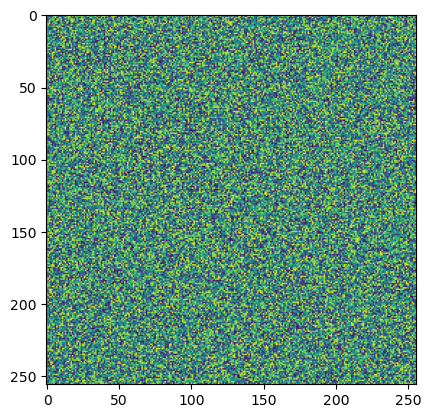

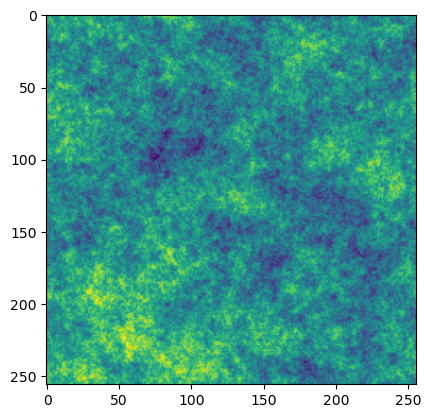

In [7]:

# create a n x n real array with colored noise of spectral power p(k) propto k^-alpha (colored noise)
# arguments: 
#    n dimensions for square array
#    alpha: - index of power spectrum; determines color of noise in image 
#    sig:   standard deviation of returned image 
# returns: 
#  nxn real array - mean is set to zero, standard deviation scaled to sig
# pink is 1/f which would have alpha=1
def mkpink(n,alpha,sig):
    whitenoise = np.random.uniform(0, 1, (n, n))  # uniform random between [0,1] in an nxn grid
    ft_arr = np.fft.fft2(whitenoise) # not using rfft2 because I need to construct square frequency array 
    d=1.
    freqs = np.fft.fftfreq(n,d)  # with sample spacing of d=1
    k_x,k_y = np.meshgrid(freqs,freqs)
    #k =  np.hypot(k_x,k_y)  # sqrt(k_x^2 + k_y^2)
    k = np.sqrt(k_x**2 + k_y**2)
    jj = (k == 0 )
    k[jj] = 1e-6  # get rid of zero value 
    pink_ft_arr = ft_arr / np.power(k,alpha/2)
    # fft_arr is fourier ammplitudes and amplitude is sqrt of power 
    # if alpha=1 we have 1/f noise which is called pink noise 
    pinknoise = np.real(np.fft.ifft2(pink_ft_arr)) # take real part 
    meanval = np.mean(pinknoise)
    pinknoise -= meanval # substract of mean value 
    std_pink = np.std(pinknoise)
    pinknoise *= sig/std_pink # set standard deviation  of returned image 
    #print(ft_arr.shape)
    #print(k.shape)
    return pinknoise

sig = 0.5
pink = mkpink(256,-0.1,sig) # nearly white 
plt.imshow(pink)
plt.show()
pink = mkpink(256,2,sig) # pink
plt.imshow(pink)
plt.show()

In [8]:
# set pinknoise initial conditions into gfu
# parameters:
#  gfu is output grid function, already allocated 
#  mesh: ngsolve mesh
#  sigu,sigv: standard deviation in both fields 
#  alphau,alphav: powerlaw spectral index of noise 
#  u0, v0 constant offsets for initial conditions
# returns: nothing, but fills/overwrites gfu
def mkinit_pink(gfu,mesh,sigu,sigv,alphau,alphav,u0,v0):

    # output fields 
    u1_out = gfu.components[0]
    u2_out = gfu.components[1]
    r1  = u1_out.vec.CreateVector()  # create two vectors 
    r2  = u1_out.vec.CreateVector()

    # use the bounding box to find min and max range of x and y values 
    netgen_mesh = mesh.ngmesh
    p1,p2 = netgen_mesh.bounding_box
    #print(p1,p2)
    xxmin = min(p1[0],p2[0])
    xxmax = max(p1[0],p2[0])
    yymin = min(p1[1],p2[1])
    yymax = max(p1[1],p2[1])  # we could use these to coordinate transform our noise 
    nv = mesh.nv
    dx = xxmax - xxmin
    dy = yymax - yymin
    dxymax = max(dx,dy)
    x2 = xxmin + dxymax
    y2 = yymin + dxymax 
    dd = np.sqrt(dxymax**2/nv) # average distance between particles 
    nft = int(2*dxymax/dd) # how big an fft we need 
    print(nft)

    pinknoiseu = mkpink(nft,alphau,sigu) # make an fft image with appropriate noise in it 
    pinknoisev = mkpink(nft,alphav,sigv) # make an fft image with appropriate noise in it 
    paramCFu = ngsolve.VoxelCoefficient(\
        start=(xxmin, yymin), end=(x2, y2),\
        values=pinknoiseu, linear=True).Compile()  # returns a coefficient function which interpolates from the given grid of values 
    paramCFv = ngsolve.VoxelCoefficient(\
        start=(xxmin, yymin), end=(x2, y2),\
        values=pinknoisev, linear=True).Compile()  # returns a coefficient function which interpolates from the given grid of values 


    u1_out.Set(u0 + paramCFu)  # set to a positive constant 
    u2_out.Set(v0 + paramCFv)  # set to a constant 

    #return paramCF,pinknoise


In [10]:
# https://docu.ngsolve.org/latest/i-tutorials/unit-4.1.2-csg2d/csg2d.html
geo = netgen.geom2d.CSG2d()

# make a circle with a hole in it!
circle1 = netgen.geom2d.Circle( center=(0,0), radius=1.0,  bc="outer" )
circle2 = netgen.geom2d.Circle( center=(0.2,0), radius=0.3,  bc="inner" )

annulus = circle1 - circle2
geo.Add(annulus)

# generate the  mesh
maxh_mesh = 0.03  # max distance between nodes?
mesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh))  # maxh here sets the scale of elements 
print(f"vertices={mesh.nv}, edges ={mesh.ne}")  # print numbers of vertices and edges!

Draw(mesh) # show the mesh

# create finite element system 'fes'  - we have two fields for the reaction diffusion equations 
korder = 3
Q1 = ngsolve.H1(mesh, order=korder)   # Choose an element that is in the Sobolev space H1, first field
Q2 = ngsolve.H1(mesh, order=korder)   # second field
fes = Q1*Q2   # our finite element space is the product of the two spaces 
#(u1,u2),(v1,v2)  = fes.TnT()  # create test and trial functions  
# The two test fields are u1,u2 and the trial functions are v1,v2
# in our equations the fields were u,v but here we have u=u1 and v=u2     
# in our equations the trial functions were both w, and here they are v1 and v2

#gfu = ngsolve.GridFunction(fes) # to hold the solution 

# output fields 
#u1_out = gfu.components[0]
#u2_out = gfu.components[1]

# xv,yv,tri_tt,refiner = pts_tri(mesh)  # needed for making pngs 

vertices=3552, edges =6832


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [53]:
dt = 0.01  # timestep
D_u = 1.0e-3  # diffusion coefficients for reaction diffusion equations 
D_v = D_u*11
rdtype = 'Br'   # doing a Brusselator reaction diffusion model 
print(maxh_mesh**2/D_u,maxh_mesh**2/D_v )  # both of these should be larger than dt
# this is a CFL like condition for numerical stability
# CHECK that our dt is lower than these !!!!!!

# make the operators 
#invastar,a,b,invm = mkops(fes,D_u,D_v,dt)

0.8999999999999999 0.08181818181818182


In [54]:
gfu = ngsolve.GridFunction(fes)
mkinit(gfu,mesh,0.1,4,1)  # make initial conditions and show them, out of equilibrium base
# first number is random sig, second two are base levels of u,v 
scene = Draw(gfu.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

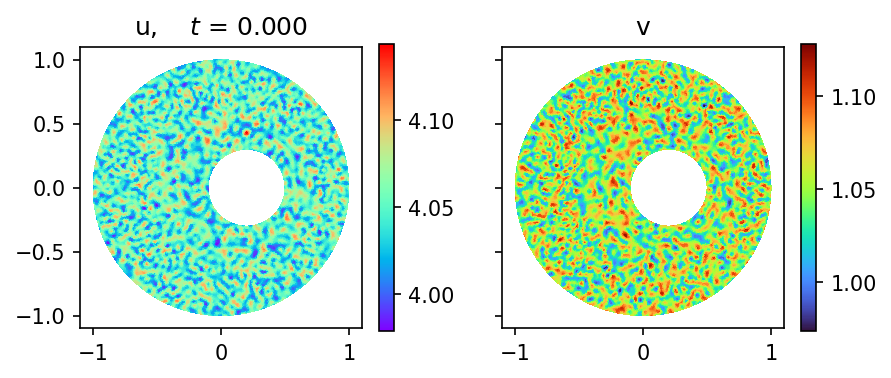

In [55]:
disp(mesh,gfu,0,'')    # make a png so we can see what the last output looked like
# these are illustrating our initial conditions 

In [56]:
alpha = 5.; beta = 9.  # choose some nice Brusselator params
print(beta/alpha) # v0 value for steady state solution , u0 value = alpha

1.8


In [57]:
gfu = ngsolve.GridFunction(fes); gfu2 = ngsolve.GridFunction(fes) 
mkinit(gfu,mesh,0.1,4,1)  # make initial conditions and show them, out of equilibrium base
# first number is random sig, second two are base levels of u,v 
scene = Draw(gfu.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 
gfu2.vec.data = gfu.vec.data  # copying initial conditions over to gfu2

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

In [58]:

dt = 0.0025  # timestep
D_u = 1.5e-3  # diffusion coefficients for reaction diffusion equations 
D_v = D_u*11
rdtype = 'Br'   # doing a Brusselator reaction diffusion model 
invastar,a_lap,b_op,invm = mkops(fes,D_u,D_v,dt)  # make operators 
alpha = 5.; beta = 9.  # choose some nice Brusselator params
gfut_CN = TimeStepping_CN(fes,gfu,scene,invastar, a_lap,invm, rdtype, alpha, beta, dt, tend=10,nsamples=100,reaction_by_hand = True)

 9.997500000000153576

In [59]:
scene = Draw(gfu2.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

In [60]:
gfut_CN = TimeStepping_CN(fes,gfu2,scene,invastar, a_lap,invm, rdtype, alpha, beta, dt, tend=10,nsamples=100,reaction_by_hand = False)

craete bilinearformapplication
 9.997500000000153576

## reaction by hand is faster because no reassembly required
## The reaction by hand true gave more sensitivity to boundary with the same initial conditions !!!!

Alignment with boundary in by hand was still present at small step sizes. 

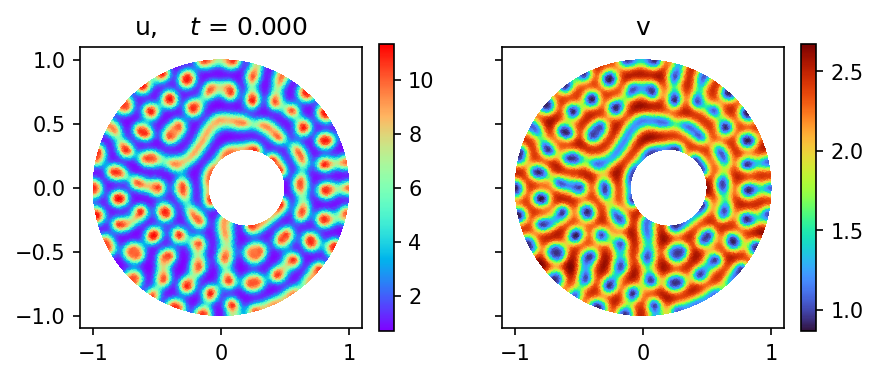

In [61]:
#xv,yv,tri_tt,refiner = pts_tri(mesh)
disp(mesh,gfu,0,'')    # make a png so we can see what the last output looked like

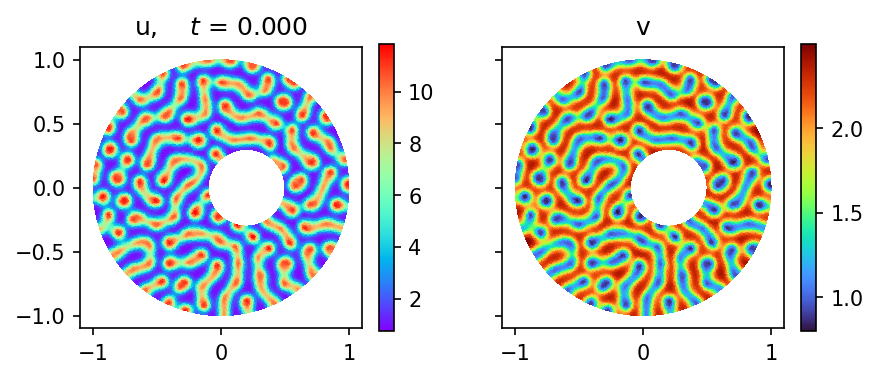

In [43]:
disp(mesh,gfu2,0,xv,yv,tri_tt,refiner,'')    # make a png so we can see what the last output looked like

In [ ]:
# let's look at pink noise in the same kind of system

In [62]:
gfu = ngsolve.GridFunction(fes); gfu2 = ngsolve.GridFunction(fes) 
#mkinit(gfu,mesh,0.1,4,1)  # make initial conditions and show them, out of equilibrium base
# first number is random sig, second two are base levels of u,v 
sigu = 0.1; sigv = 0.1; alphau = 2; alphav=2; u0 = 4; v0=1.0
mkinit_pink(gfu,mesh,sigu,sigv,alphau,alphav,u0,v0)
scene = Draw(gfu.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 
gfu2.vec.data = gfu.vec.data  # copying initial conditions over to gfu2

119


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

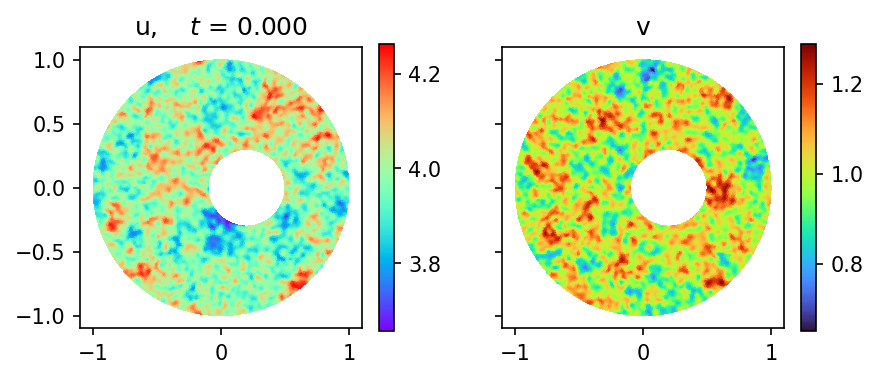

In [63]:
disp(mesh,gfu,0,'')    # make a png so we can see pink initial conditions

In [64]:
scene = Draw(gfu.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

In [65]:
dt = 0.0025  # timestep
D_u = 1.5e-3  # diffusion coefficients for reaction diffusion equations 
D_v = D_u*11
rdtype = 'Br'   # doing a Brusselator reaction diffusion model 
invastar,a_lap,b_op,invm = mkops(fes,D_u,D_v,dt)  # make operators 
alpha = 5.; beta = 9.  # choose some nice Brusselator params
gfut_CN = TimeStepping_CN(fes,gfu,scene,invastar, a_lap,invm, rdtype, alpha, beta, dt, tend=10,nsamples=100,reaction_by_hand = True)

 9.997500000000153576

In [66]:
scene = Draw(gfu2.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

In [67]:
gfut_CN = TimeStepping_CN(fes,gfu2,scene,invastar, a_lap,invm, rdtype, alpha, beta, dt, tend=10,nsamples=100,reaction_by_hand = False)

craete bilinearformapplication
 9.997500000000153576

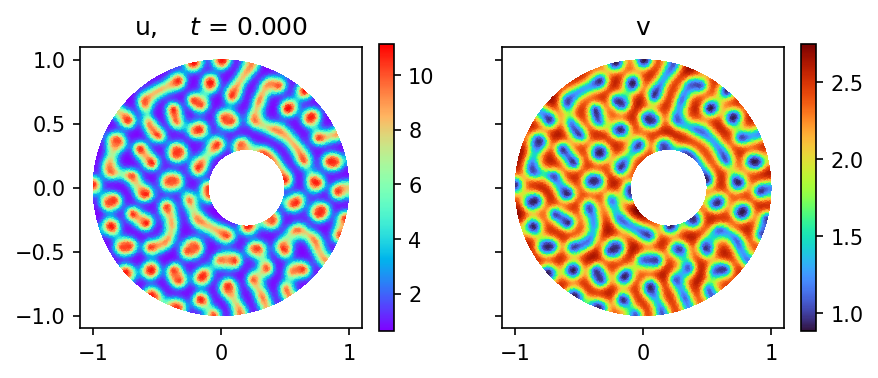

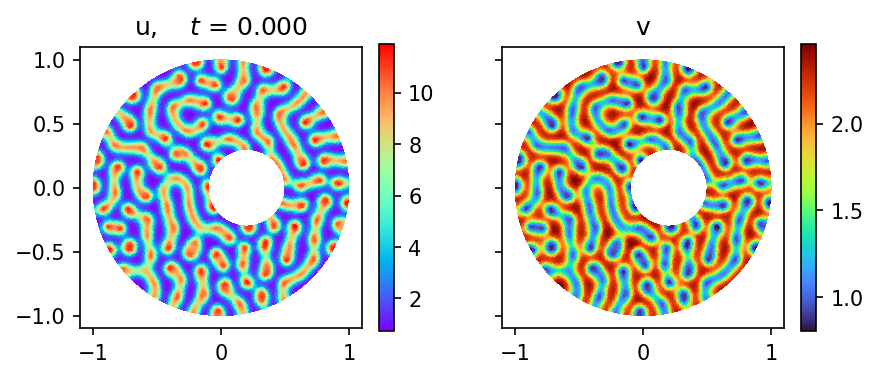

In [68]:
disp(mesh,gfu,0,'')    
disp(mesh,gfu2,0,'')    # make a png  

In [22]:
# let's check grid resolution 
# https://docu.ngsolve.org/latest/i-tutorials/unit-4.1.2-csg2d/csg2d.html
geo = netgen.geom2d.CSG2d()

# make a circle with a hole in it!
circle1 = netgen.geom2d.Circle( center=(0,0), radius=1.0,  bc="outer" )
circle2 = netgen.geom2d.Circle( center=(0.2,0), radius=0.3,  bc="inner" )

annulus = circle1 - circle2
geo.Add(annulus)

# generate the  mesh
maxh_mesh = 0.07  # max distance between nodes?
mesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh))  # maxh here sets the scale of elements 
print(f"vertices={mesh.nv}, edges ={mesh.ne}")  # print numbers of vertices and edges!

Draw(mesh) # show the mesh
korder = 4
Q1 = ngsolve.H1(mesh, order=korder)   # Choose an element that is in the Sobolev space H1, first field
Q2 = ngsolve.H1(mesh, order=korder)   # second field
fes = Q1*Q2   # our finite element space is the product of the two spaces 

vertices=658, edges =1200


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [23]:
gfu = ngsolve.GridFunction(fes); gfu2 = ngsolve.GridFunction(fes) 
mkinit(gfu,mesh,0.1,4,1)  # make initial conditions and show them, out of equilibrium base
# first number is random sig, second two are base levels of u,v 
scene = Draw(gfu.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 
gfu2.vec.data = gfu.vec.data  # copying initial conditions over to gfu2

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

In [24]:
dt = 0.01  # timestep
D_u = 1.5e-3  # diffusion coefficients for reaction diffusion equations 
D_v = D_u*11
rdtype = 'Br'   # doing a Brusselator reaction diffusion model 
invastar,a_lap,b_op,invm = mkops(fes,D_u,D_v,dt)  # make operators 
alpha = 5.; beta = 9.  # choose some nice Brusselator params
gfut_CN = TimeStepping_CN(fes,gfu,scene,invastar, a_lap,invm, rdtype, alpha, beta, dt, tend=10,nsamples=100,reaction_by_hand = True)



 9.989999999999831575

In [25]:
scene = Draw(gfu2.components[0],mesh, settings = {  "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False} } );  # 

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

In [26]:
gfut_CN = TimeStepping_CN(fes,gfu2,scene,invastar, a_lap,invm, rdtype, alpha, beta, dt, tend=10,nsamples=100,reaction_by_hand = False)

craete bilinearformapplication
 9.989999999999831575

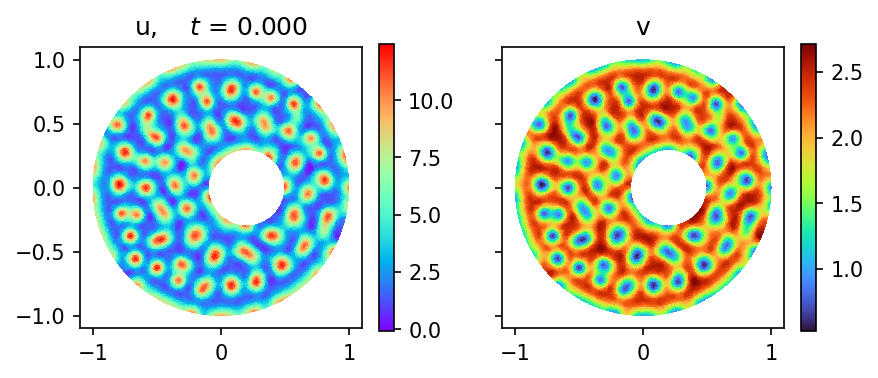

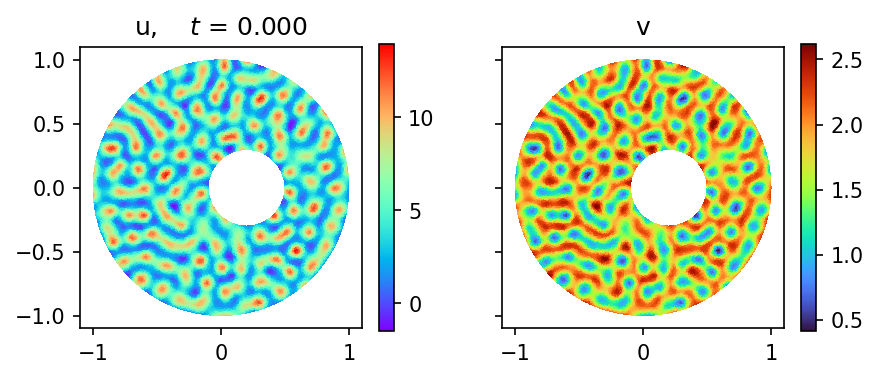

In [27]:
disp(mesh,gfu,0,'')    
disp(mesh,gfu2,0,'')    # make a png  

## I ran this with order 4 and things were not that bad even though grid is not all that fine!
## take home message: is don't use by hand non-linear update!
## when I ran this with with order 2, things were really bad in the by-hand non-linear update 

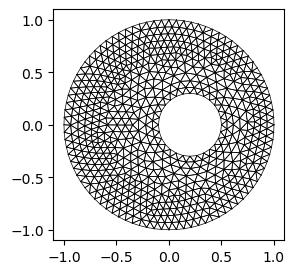

In [35]:


draw_mesh(mesh)

In [8]:
# https://docu.ngsolve.org/latest/i-tutorials/unit-4.1.2-csg2d/csg2d.html
geo = netgen.geom2d.CSG2d()

# make a circle with a hole in it!
circle1 = netgen.geom2d.Circle( center=(0,0), radius=1.0,  bc="outer" )
circle2 = netgen.geom2d.Circle( center=(0.1,0), radius=0.3,  bc="inner" )
tri_angle = 30.0*np.pi/180  # half angle of peak
h_tri = np.cos(tri_angle)  #height of triangle with base 1, with center of base at 0,0
mtriangle = netgen.geom2d.Solid2d( [\
    (-0.5,0.0) ,netgen.geom2d.EdgeInfo(bc="tri-bot"),
    (0.5,0.0),netgen.geom2d.EdgeInfo(bc="tri-right"),
    (0,h_tri), netgen.geom2d.EdgeInfo(bc="tri-left") \
     ] )
mtriangle.Scale(1.2) 
mtriangle.Move((0.0,-0.2))
mtriangle2 = netgen.geom2d.Solid2d( [\
    (-0.5,0.0) ,netgen.geom2d.EdgeInfo(bc="tri-bot"),
    (0.5,0.0),netgen.geom2d.EdgeInfo(bc="tri-right"),
    (0,h_tri), netgen.geom2d.EdgeInfo(bc="tri-left") \
     ] )
mtriangle2.Scale(2.0)
annulus = mtriangle2 - circle2
geo.Add(annulus)

# generate the  mesh
maxh_mesh = 0.03  # max distance between nodes?
mesh3 = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh))  # maxh here sets the scale of elements 
#print(f"vertices={mesh.nv}, edges ={mesh.ne}")  # print numbers of vertices and edges!

Draw(mesh3) # show the mesh



WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

BaseWebGuiScene